# Visualisation & Storytelling : Early Warning des demandes d’asile

## Objectif

Ce notebook prépare la future modélisation Machine Learning en répondant à une question métier :

> **Quels signaux historiques permettent d’identifier les corridors origine → pays d’asile susceptibles de connaître une hausse significative des demandes l’année suivante ?**

L’unité d’analyse est le **corridor–année** : un pays d’origine (`coo`) × un pays d’asile (`coa`) × une année (`year`).

Le storytelling suit le fil : **contexte → problème → définition de l’alerte → signaux → qualité des données → préparation du ML**.

**Important :** cette partie est exploratoire. Les associations observées ne démontrent pas une causalité et aucune performance de modèle n’est évaluée ici.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Date de cette exécution : AAAAMMJJ 
DATE_EXPORT = datetime.now().strftime("%Y%m%d")


DATA_PATH = f"../data/feature_engineering_outputs/dataset_ml_features_{DATE_EXPORT}.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head())

Dimensions : 86,234 lignes × 20 colonnes


,year,coo_id,coa_id,coa_name,coo_name,origin_region,asylum_region,applied,applied_lag1,applied_lag2,growth_past_1,absolute_change_past_1,acceleration,two_consecutive_increases,origin_applied_total_t,asylum_applied_total_t,segment_share_origin_t,segment_share_asylum_t,idmc_total_origin_lag1,applied_t1
0,2019,10,109,Lebanon,Armenia,WESTERN ASIA,WESTERN ASIA,5,NaN,NaN,NaN,NaN,NaN,NaN,6766,3610,0.001,0.001,NaN,0.000
1,2021,10,109,Lebanon,Armenia,WESTERN ASIA,WESTERN ASIA,5,NaN,5.000,NaN,NaN,NaN,NaN,5573,1141,0.001,0.004,800.000,10.000
2,2022,10,109,Lebanon,Armenia,WESTERN ASIA,WESTERN ASIA,10,5.000,NaN,1.000,5.000,NaN,NaN,11096,2154,0.001,0.005,800.000,0.000
3,2000,10,11,Australia,Armenia,WESTERN ASIA,AUSTRALIA-NEW ZEALAND,19,NaN,NaN,NaN,NaN,NaN,NaN,10722,19541,0.002,0.001,NaN,10.000
4,2001,10,11,Australia,Armenia,WESTERN ASIA,AUSTRALIA-NEW ZEALAND,10,19.000,NaN,-0.474,-9.000,NaN,NaN,11838,18067,0.001,0.001,NaN,10.000


## 1. Contrôles préalables

Avant de raconter l’histoire des données, on vérifie que la granularité attendue est respectée et que les années sont cohérentes. Un doublon sur `(coo_id, coa_id, year)` signifierait que l’unité corridor–année n’est pas unique.

In [14]:
print("Période :", df["year"].min(), "→", df["year"].max())
print("Corridor-années en doublon :", df.duplicated(["coo_id", "coa_id", "year"]).sum())
print("Valeurs négatives de applied :", (df["applied"] < 0).sum())
print("Valeurs manquantes de applied :", df["applied"].isna().sum())

Période : 2000 → 2025
Corridor-années en doublon : 0
Valeurs négatives de applied : 0
Valeurs manquantes de applied : 0


### Lecture

Le contrôle de granularité doit être validé avant toute agrégation ou modélisation. Les variables de T+1 seront ensuite traitées séparément car elles appartiennent au futur par rapport à l’année d’observation.

# ACTE 1 — Le contexte : les demandes évoluent fortement dans le temps

## 2. Comment le volume mondial des demandes évolue-t-il ?

On commence par le phénomène métier lui-même, avant de regarder la cible ML.

,year,applied,growth_pct
16,2016,2128703,-9.379
17,2017,1875359,-11.901
18,2018,2091460,11.523
19,2019,2245518,7.366
20,2020,1269579,-43.462
21,2021,1724859,35.861
22,2022,2904909,68.414
23,2023,3848894,32.496
24,2024,3421776,-11.097
25,2025,3343203,-2.296


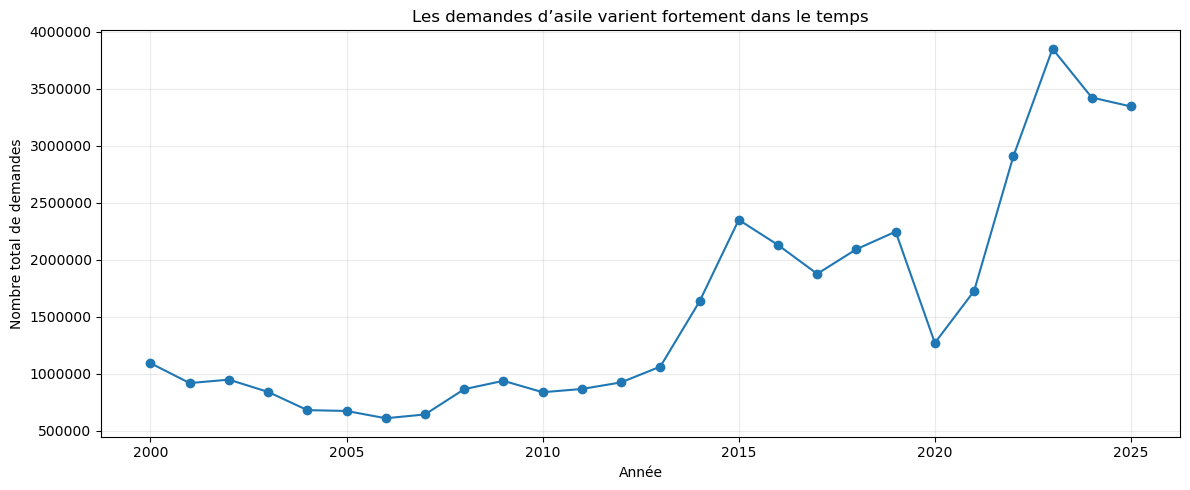

In [3]:
yearly = df.groupby("year", as_index=False)["applied"].sum()
yearly["growth_pct"] = yearly["applied"].pct_change() * 100

display(yearly.tail(10))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly["year"], yearly["applied"], marker="o")
ax.set_title("Les demandes d’asile varient fortement dans le temps")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre total de demandes")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interprétation

La série n’est pas stable : elle comporte des phases d’accélération, de recul et de reprise. Cette variabilité justifie une approche temporelle. Pour le futur ML, un découpage aléatoire serait donc moins approprié qu’un **split chronologique**.

**Transition :** le volume global est très dynamique, mais cette dynamique est-elle concentrée sur certains pays ?

# ACTE 2 — Le phénomène est aussi très concentré géographiquement

## 3. Quels pays d’origine cumulent le plus de demandes ?

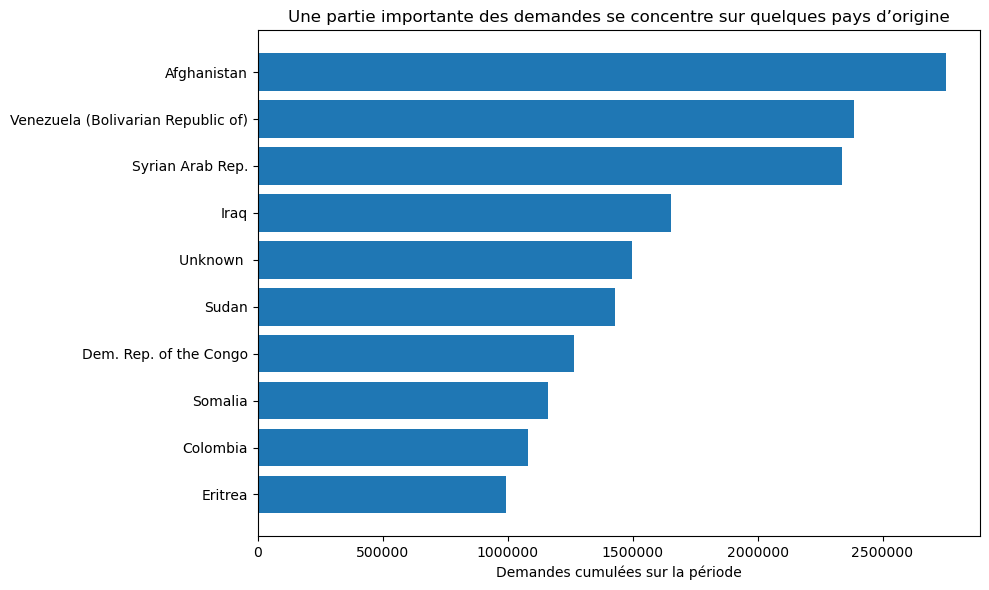

In [4]:
top_origin = (df.groupby("coo_name", as_index=False)["applied"].sum()
              .sort_values("applied", ascending=False).head(10)
              .sort_values("applied"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_origin["coo_name"], top_origin["applied"])
ax.set_title("Une partie importante des demandes se concentre sur quelques pays d’origine")
ax.set_xlabel("Demandes cumulées sur la période")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interprétation

Les volumes ne sont pas répartis uniformément entre les origines. Cela suggère que le **contexte du pays d’origine** et le poids relatif d’un corridor peuvent apporter une information complémentaire au simple volume du corridor.

## 4. Quels pays d’asile concentrent le plus de demandes ?

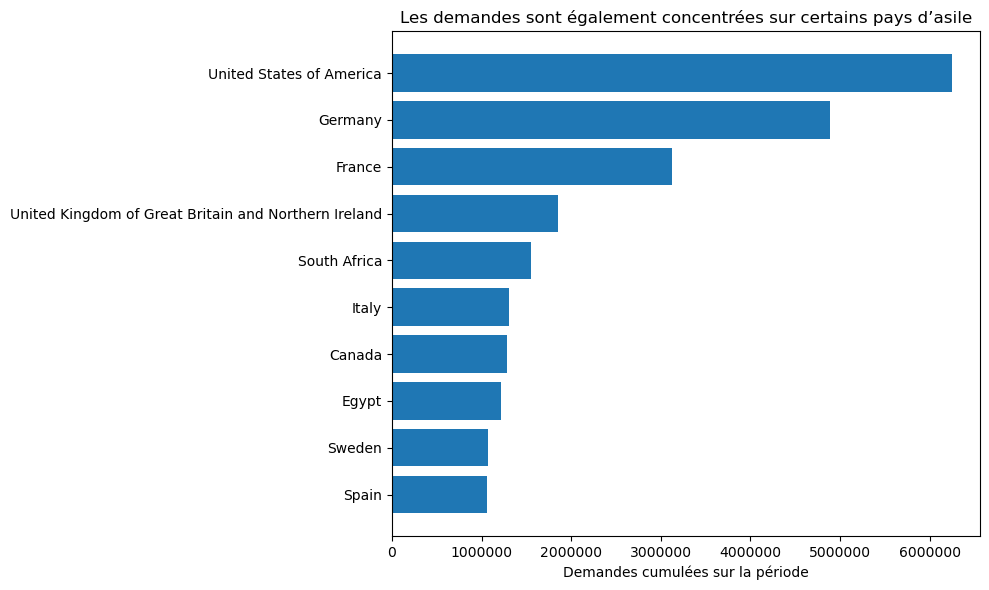

In [5]:
top_asylum = (df.groupby("coa_name", as_index=False)["applied"].sum()
              .sort_values("applied", ascending=False).head(10)
              .sort_values("applied"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_asylum["coa_name"], top_asylum["applied"])
ax.set_title("Les demandes sont également concentrées sur certains pays d’asile")
ax.set_xlabel("Demandes cumulées sur la période")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interprétation

Le pays d’asile constitue lui aussi un contexte important. Deux corridors ayant le même volume courant peuvent évoluer différemment selon leur origine, leur destination et leur poids dans les flux totaux.

**Transition :** pour transformer cette dynamique en problème prédictif, il faut maintenant définir précisément ce que l’on appelle une alerte future.

# ACTE 3 — Définir le phénomène à anticiper

## 5. Construction de la cible exploratoire `target_escalade`

Une alerte vaut **1** si, entre l’année T et T+1 :

- le nombre de demandes augmente d’au moins **30 %** ;
- **et** l’augmentation absolue est d’au moins **100 demandes**.

Sinon elle vaut 0. Lorsque T+1 n’existe pas, la cible reste manquante : on ne transforme jamais une année non observable en absence d’alerte.

Cette cible sert ici à comprendre les associations entre les signaux historiques et les hausses futures. `applied_t1` ne devra **jamais** être utilisé comme feature ML.

In [15]:
df["absolute_change_t1"] = df["applied_t1"] - df["applied"]

df["target_escalade"] = np.where(
    df["applied_t1"].isna(),
    np.nan,
    (
        (df["applied_t1"] >= 1.30 * df["applied"]) &
        (df["absolute_change_t1"] >= 100)
    ).astype(int)
)

labeled = df.dropna(subset=["target_escalade"]).copy()
labeled["target_escalade"] = labeled["target_escalade"].astype(int)

print(f"Observations labellisées : {len(labeled):,}")
print(f"Alertes positives : {labeled['target_escalade'].sum():,}")
print(f"Taux d’alerte : {labeled['target_escalade'].mean():.2%}")

print()
print("Observations sans T+1 par année :")
display(df.loc[df["applied_t1"].isna(), "year"].value_counts().sort_index().rename("n"))

Observations labellisées : 82,267
Alertes positives : 6,467
Taux d’alerte : 7.86%

Observations sans T+1 par année :


year
2025    3967
Name: n, dtype: int64

### Interprétation

La cible positive est minoritaire. C’est une information essentielle pour la suite : **l’accuracy seule ne sera pas une métrique suffisante**. La future modélisation devra particulièrement suivre le rappel, la précision, le F1-score, la PR-AUC et la matrice de confusion.

## 6. La fréquence des alertes est-elle stable dans le temps ?

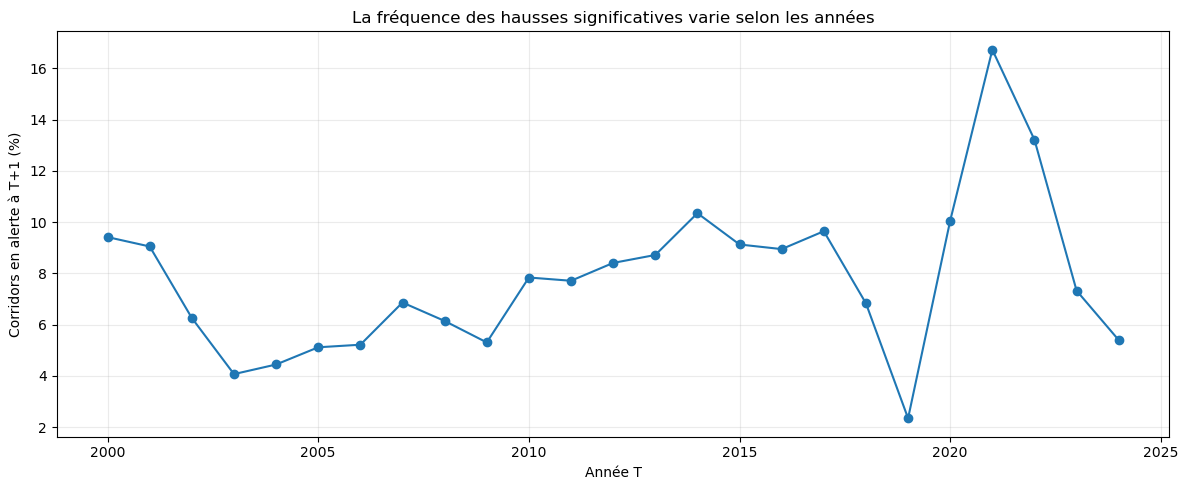

In [7]:
alert_year = (labeled.groupby("year", as_index=False)["target_escalade"]
              .agg(alert_rate="mean", n_alerts="sum", n_obs="count"))
alert_year["alert_rate_pct"] = alert_year["alert_rate"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(alert_year["year"], alert_year["alert_rate_pct"], marker="o")
ax.set_title("La fréquence des hausses significatives varie selon les années")
ax.set_xlabel("Année T")
ax.set_ylabel("Corridors en alerte à T+1 (%)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interprétation

La proportion d’alertes change selon les périodes. Le modèle devra donc apprendre sur le passé et être évalué sur des périodes futures distinctes, afin de reproduire une situation réelle d’anticipation.

**Transition :** quels signaux disponibles à T sont associés à ces alertes futures ?

# ACTE 4 — Rechercher les signaux historiques

## 7. Le volume actuel du corridor est-il associé au risque d’alerte ?

,volume_class,n,alert_rate,alert_rate_pct
0,1–10,28239,0.008,0.793
1,11–50,24107,0.029,2.858
2,51–100,7800,0.091,9.077
3,101–500,13101,0.199,19.937
4,501–1 000,3392,0.265,26.504
5,1 001–5 000,4309,0.245,24.530
6,>5 000,1319,0.211,21.077


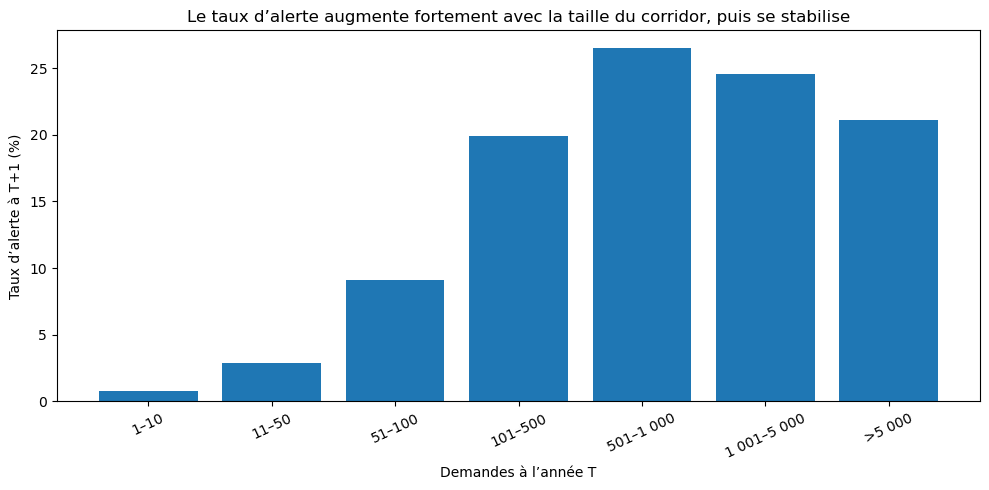

In [8]:
volume_bins = [-1, 10, 50, 100, 500, 1000, 5000, np.inf]
volume_labels = ["1–10", "11–50", "51–100", "101–500", "501–1 000", "1 001–5 000", ">5 000"]

labeled["volume_class"] = pd.cut(labeled["applied"], bins=volume_bins, labels=volume_labels)
vol_alert = (labeled.groupby("volume_class", observed=True)["target_escalade"]
             .agg(n="count", alert_rate="mean").reset_index())
vol_alert["alert_rate_pct"] = vol_alert["alert_rate"] * 100

display(vol_alert)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(vol_alert["volume_class"].astype(str), vol_alert["alert_rate_pct"])
ax.set_title("Le taux d’alerte augmente fortement avec la taille du corridor, puis se stabilise")
ax.set_xlabel("Demandes à l’année T")
ax.set_ylabel("Taux d’alerte à T+1 (%)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Interprétation

Les très petits corridors déclenchent rarement la règle d’alerte, notamment parce que celle-ci exige aussi une hausse absolue de 100 demandes. Le volume courant contient donc un signal important, mais la relation n’est pas simplement linéaire.

## 8. La croissance récente apporte-t-elle un signal supplémentaire ?

,growth_class,n,alert_rate,alert_rate_pct
0,≤ -50%,9666,0.073,7.325
1,-50 à -10%,16160,0.072,7.240
2,-10 à 0%,7670,0.051,5.150
3,0 à 10%,2772,0.121,12.085
4,10 à 50%,10560,0.098,9.754
5,50 à 100%,6798,0.113,11.312
6,> 100%,10044,0.151,15.114


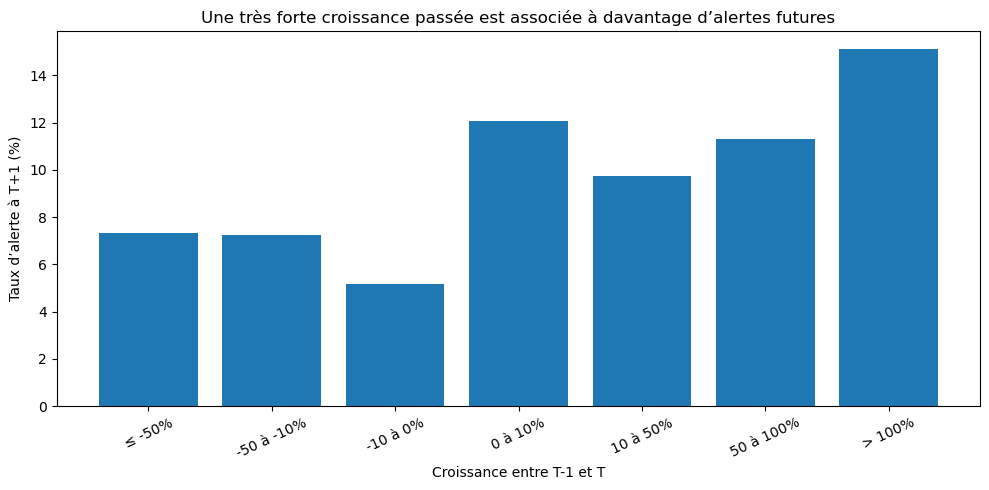

In [9]:
growth_bins = [-np.inf, -0.50, -0.10, 0, 0.10, 0.50, 1.00, np.inf]
growth_labels = ["≤ -50%", "-50 à -10%", "-10 à 0%", "0 à 10%", "10 à 50%", "50 à 100%", "> 100%"]

labeled["growth_class"] = pd.cut(labeled["growth_past_1"], bins=growth_bins, labels=growth_labels)
growth_alert = (labeled.groupby("growth_class", observed=True)["target_escalade"]
                .agg(n="count", alert_rate="mean").reset_index())
growth_alert["alert_rate_pct"] = growth_alert["alert_rate"] * 100

display(growth_alert)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(growth_alert["growth_class"].astype(str), growth_alert["alert_rate_pct"])
ax.set_title("Une très forte croissance passée est associée à davantage d’alertes futures")
ax.set_xlabel("Croissance entre T-1 et T")
ax.set_ylabel("Taux d’alerte à T+1 (%)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Interprétation

La relation n’est pas parfaitement monotone : une seule mesure de croissance ne suffit donc pas à expliquer les futures hausses. Cela soutient l’intérêt de combiner volume, croissance, variations absolues et contexte du corridor.

## 9. Deux hausses consécutives constituent-elles un signal de persistance ?

,situation,n,alert_rate_pct
0,Non,41778,8.567
1,Oui,12223,15.340


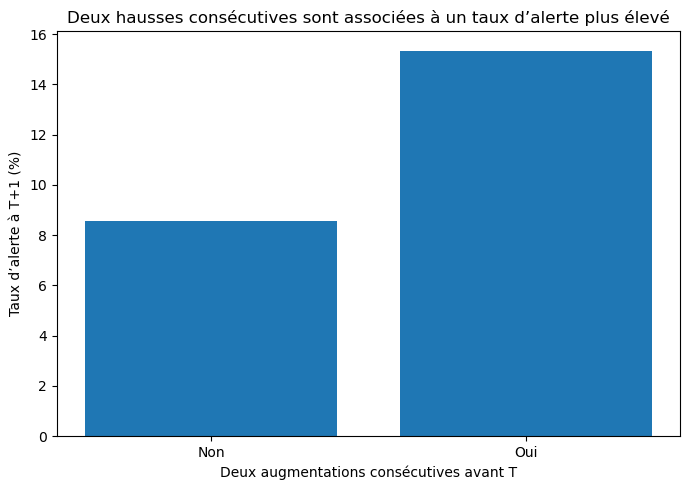

In [10]:
consecutive = (labeled.dropna(subset=["two_consecutive_increases"])
               .groupby("two_consecutive_increases")["target_escalade"]
               .agg(n="count", alert_rate="mean").reset_index())
consecutive["situation"] = consecutive["two_consecutive_increases"].map({0.0: "Non", 1.0: "Oui"})
consecutive["alert_rate_pct"] = consecutive["alert_rate"] * 100

display(consecutive[["situation", "n", "alert_rate_pct"]])

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(consecutive["situation"], consecutive["alert_rate_pct"])
ax.set_title("Deux hausses consécutives sont associées à un taux d’alerte plus élevé")
ax.set_xlabel("Deux augmentations consécutives avant T")
ax.set_ylabel("Taux d’alerte à T+1 (%)")
plt.tight_layout()
plt.show()

### Interprétation

La persistance des hausses apporte un signal distinct. Il s’agit d’une **association**, pas d’une causalité : le futur modèle devra déterminer comment ce signal se combine avec les autres variables.

## 10. Le contexte géographique est-il associé à des taux d’alerte différents ?

Pour éviter de surinterpréter de très petits groupes, on affiche uniquement les régions ayant au moins 500 observations labellisées.

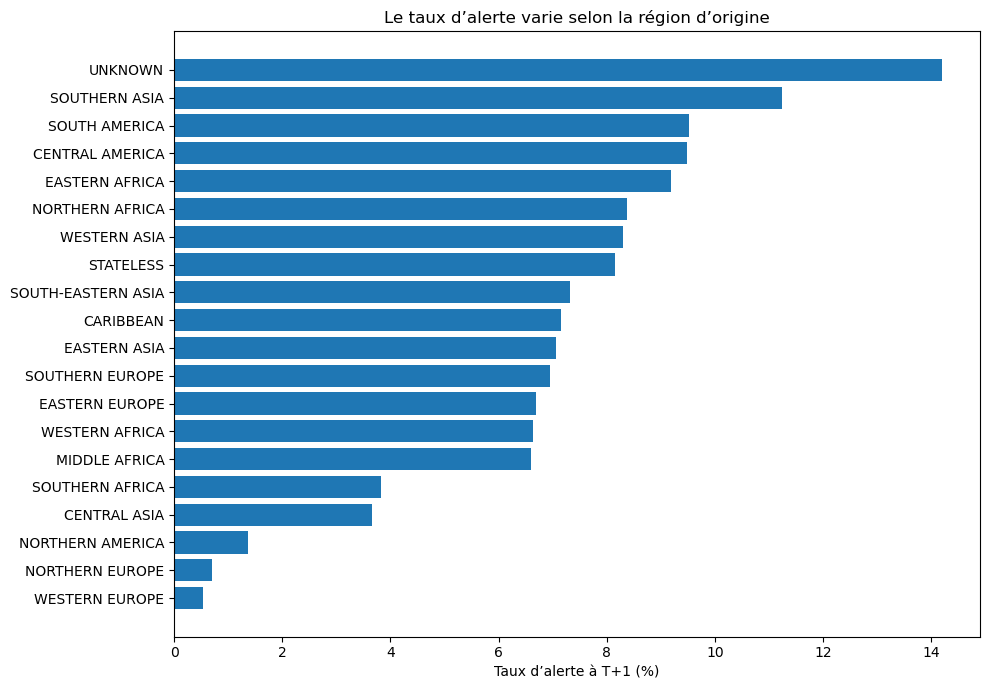

In [11]:
region_alert = (labeled.groupby("origin_region")["target_escalade"]
                .agg(n="count", alert_rate="mean").reset_index())
region_alert = region_alert[region_alert["n"] >= 500].copy()
region_alert["alert_rate_pct"] = region_alert["alert_rate"] * 100
region_alert = region_alert.sort_values("alert_rate_pct")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(region_alert["origin_region"], region_alert["alert_rate_pct"])
ax.set_title("Le taux d’alerte varie selon la région d’origine")
ax.set_xlabel("Taux d’alerte à T+1 (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Interprétation

Les différences régionales montrent que le phénomène n’est pas homogène spatialement. Elles ne signifient pas qu’une région « cause » une hausse : elles peuvent refléter de multiples contextes historiques et géopolitiques non observés dans ce dataset.

Pour le ML, `origin_region` et `asylum_region` sont donc des variables contextuelles candidates, à encoder correctement.

# ACTE 5 — Avant le ML : comprendre les limites des données

## 11. Quelles variables présentent des valeurs manquantes ?

,variable,missing_pct
0,idmc_total_origin_lag1,64.102
1,two_consecutive_increases,33.885
2,acceleration,33.885
3,applied_lag2,28.302
4,absolute_change_past_1,22.354
5,growth_past_1,22.354
6,applied_lag1,22.354
7,absolute_change_t1,4.600
8,applied_t1,4.600
9,target_escalade,4.600


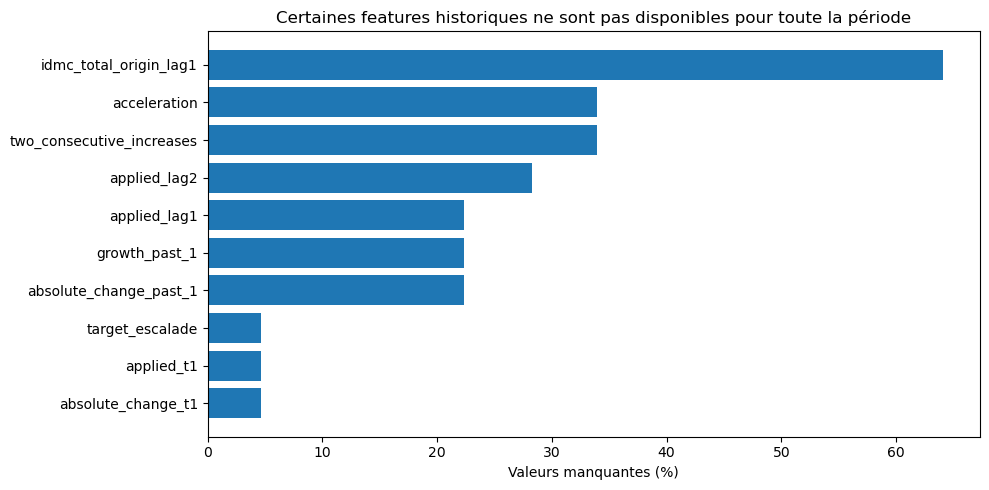

In [12]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0].reset_index()
missing.columns = ["variable", "missing_pct"]

display(missing)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing.sort_values("missing_pct")["variable"],
        missing.sort_values("missing_pct")["missing_pct"])
ax.set_title("Certaines features historiques ne sont pas disponibles pour toute la période")
ax.set_xlabel("Valeurs manquantes (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Interprétation

Les valeurs manquantes des `lag` et des variables dérivées peuvent être **structurelles** : les premières observations d’un corridor ne disposent pas toujours d’un historique suffisant. Il faut donc éviter de supprimer automatiquement toutes ces lignes.

`idmc_total_origin_lag1` mérite une attention particulière car sa couverture est nettement plus faible. Avant le ML, il faudra déterminer si cette absence correspond à des années/pays non couverts, à une absence d’événement IDMC, ou à un problème de jointure. **Une valeur manquante ne doit pas être assimilée automatiquement à zéro.**

## 12. La couverture IDMC est-elle stable dans le temps ?

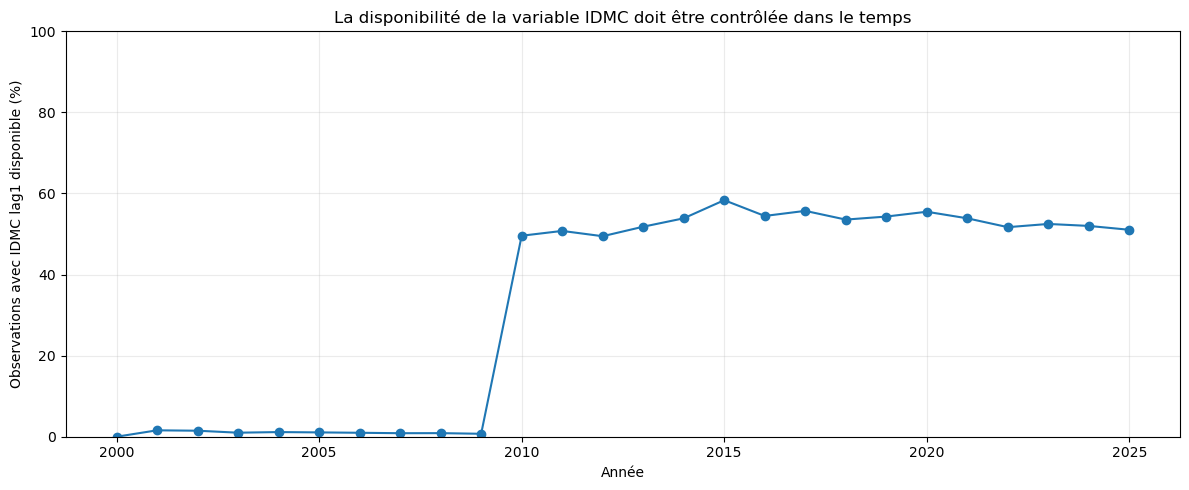

In [13]:
idmc_coverage = (df.assign(idmc_available=df["idmc_total_origin_lag1"].notna())
                 .groupby("year", as_index=False)["idmc_available"].mean())
idmc_coverage["coverage_pct"] = idmc_coverage["idmc_available"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(idmc_coverage["year"], idmc_coverage["coverage_pct"], marker="o")
ax.set_title("La disponibilité de la variable IDMC doit être contrôlée dans le temps")
ax.set_xlabel("Année")
ax.set_ylabel("Observations avec IDMC lag1 disponible (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interprétation

Si la couverture change fortement selon l’année, la variable IDMC peut introduire un signal de disponibilité plutôt qu’un signal métier. Ce point devra être traité explicitement lors de la préparation des features.

# ACTE 6 — Traduction des constats en stratégie de modélisation

## 13. Ce que le storytelling nous apprend

Les visualisations mettent en évidence plusieurs dimensions complémentaires :

1. **Temporalité** — les volumes et les taux d’alerte changent fortement selon les années.
2. **Volume** — la taille actuelle du corridor est associée à la probabilité d’une hausse significative.
3. **Dynamique récente** — croissance, variation absolue, accélération et hausses consécutives peuvent capter une dynamique que le volume seul ne représente pas.
4. **Contexte géographique** — origine et destination présentent des comportements différents.
5. **Déséquilibre de cible** — les alertes sont minoritaires ; l’accuracy seule serait trompeuse.
6. **Valeurs manquantes** — plusieurs features historiques ont une disponibilité partielle, particulièrement IDMC.

### Conséquences pour le futur notebook ML

- Construire la cible uniquement lorsque `applied_t1` existe.
- Exclure strictement `applied_t1`, `absolute_change_t1` et toute information future des features.
- Faire le **split chronologique avant l’optimisation**.
- Entraîner d’abord plusieurs modèles de référence sans tuning lourd : baseline, régression logistique, Random Forest et modèle de boosting.
- Comparer les modèles sur la **validation**, puis optimiser uniquement les meilleurs.
- Garder le **jeu de test intact jusqu’à l’évaluation finale**.
- Privilégier PR-AUC, Recall, Precision, F1, Balanced Accuracy et matrice de confusion.
- Traiter les valeurs manquantes sans confondre « information absente » et valeur zéro.

# Conclusion — Passage au Machine Learning

> **Les demandes d’asile sont fortement dynamiques et hétérogènes dans le temps et dans l’espace. Le volume actuel, la croissance récente et la persistance des hausses apportent des informations différentes sur la probabilité d’une hausse significative l’année suivante. Cependant, aucun indicateur isolé ne suffit à caractériser complètement les futures situations d’alerte.**

La question de modélisation devient donc :

> **Peut-on combiner les signaux disponibles à l’année T pour estimer la probabilité qu’un corridor origine → pays d’asile connaisse une hausse significative des demandes à T+1 ?**

Le notebook suivant pourra répondre à cette question avec une validation strictement temporelle.